In [25]:
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

print("Python version", sys.version)
print("NumPy version", np.__version__)
print("Pandas version", pd.__version__)
print("Scikit-learn version", sklearn.__version__)

Python version 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]
NumPy version 2.4.2
Pandas version 3.0.1
Scikit-learn version 1.8.0


In [26]:
#Numpy
X = np.random.randn(100, 5)
print("Размер матрицы: ", X.shape)
print("Первые 10 строк: ", X[:10])
print("Для матрицы: ")
print("Среднее значение ", X.mean())
print("СКО ", X.std())
print("Минимум ", X.min())
print("Максимум ", X.max())

print("Для каждого столбца: ")
print("Среднее значение ", X.mean(axis = 0))
print("СКО ", X.std(axis = 0))
print("Минимум ", X.min(axis = 0))
print("Максимум ", X.max(axis = 0))

print("Простая векторизация: ")
w = np.random.randn(5)
print("Вектор ", w)
y = X @ w
print("Результат", y.shape)
print("Значения: ", y[:100])

Размер матрицы:  (100, 5)
Первые 10 строк:  [[-1.22966862  0.17523983  0.56966065 -0.08455496 -0.44888441]
 [-0.16584286 -0.38194389 -0.26067076  0.90257711 -1.00521286]
 [ 1.961819   -0.17699928  1.13189204 -1.38236681 -1.70377936]
 [-0.33200427  0.75263058 -0.76951616 -0.18386129  0.06121532]
 [-1.30777445 -1.46915484  0.90073006  0.04390031 -0.93658863]
 [-1.57894021 -0.38950631  0.0345745  -0.54179895  0.94618317]
 [ 1.04277916  0.11258626 -0.0832078   0.24536355 -0.03186706]
 [-1.49524495  2.27960797  1.02627885  0.34478705 -0.16585846]
 [-0.46681576  2.18613773 -1.20026163  0.43804213  0.04537995]
 [ 1.55917704  0.19300145 -0.70168681 -0.75143148  0.5425959 ]]
Для матрицы: 
Среднее значение  -0.009187157939866701
СКО  1.026533351048699
Минимум  -3.5087799131546618
Максимум  2.998699280396984
Для каждого столбца: 
Среднее значение  [-0.07962097  0.06010026  0.03003546 -0.09795172  0.04150118]
СКО  [1.02903284 1.05280389 1.07460063 0.96226815 0.99953686]
Минимум  [-2.58267884 -2.39

In [6]:
#Pandas
df = pd.DataFrame(X, columns = ["Изменение_дохода", "Изменение_цены", "Изменение_расходов", "Изменение_ФОТ", "Изменение_прибыли"])
df['target'] = y
print("Первые 5 строк: ", df.head())
print("Размер: ", df.shape)
print("Описание: ", df.describe())
print("Пропуски: ", df.isnull())



Первые 5 строк:     Изменение_дохода  Изменение_цены  Изменение_расходов  Изменение_ФОТ  \
0          0.468922        1.275716           -0.171109       0.606631   
1          0.234334        0.414970            0.069253      -1.086638   
2          0.431884        0.645807            2.038631      -0.706163   
3         -1.437113        0.173614           -0.776162      -1.365039   
4          0.921115       -1.022975            2.293913      -0.174156   

   Изменение_прибыли    target  
0           0.768722  1.355526  
1          -0.357944 -0.371614  
2           0.493209 -0.897049  
3          -0.476076 -0.509094  
4          -0.443364 -1.646223  
Размер:  (100, 6)
Описание:         Изменение_дохода  Изменение_цены  Изменение_расходов  Изменение_ФОТ  \
count        100.000000      100.000000          100.000000     100.000000   
mean           0.110843        0.091091            0.182571       0.065973   
std            0.961242        0.956576            1.075084       1.024494   

In [7]:
print("Фильтр - только увеличение цены\n", df[df['Изменение_цены']>0])
print("Сортировка - уменьшение дохода\n", df.sort_values('Изменение_дохода', ascending = False))
df['Категории_прибыли'] = pd.cut(df['Изменение_прибыли'],
                                 bins = [-float('inf'), 0, 1, float('inf')], 
                                 labels = ['Убыток', 'Низкая_прибыль','Высокая_прибыль'])
df.groupby('Категории_прибыли')['Изменение_прибыли'].mean()

Фильтр - только увеличение цены
     Изменение_дохода  Изменение_цены  Изменение_расходов  Изменение_ФОТ  \
0           0.468922        1.275716           -0.171109       0.606631   
1           0.234334        0.414970            0.069253      -1.086638   
2           0.431884        0.645807            2.038631      -0.706163   
3          -1.437113        0.173614           -0.776162      -1.365039   
5          -0.618166        1.142323            0.618650       0.762461   
6           0.883265        0.523888            0.878474       0.050168   
10          0.877282        0.712964            0.699435      -1.102834   
12         -1.181108        0.967818           -0.871127       1.552026   
13         -0.089496        1.472968           -0.847464       0.692198   
14          1.970432        1.944337           -0.512986      -0.837745   
18          0.298593        0.661233           -1.832948       1.939169   
19         -0.991487        0.674765            0.344220      -0.13

Категории_прибыли
Убыток            -0.685947
Низкая_прибыль     0.442778
Высокая_прибыль    1.466024
Name: Изменение_прибыли, dtype: float64

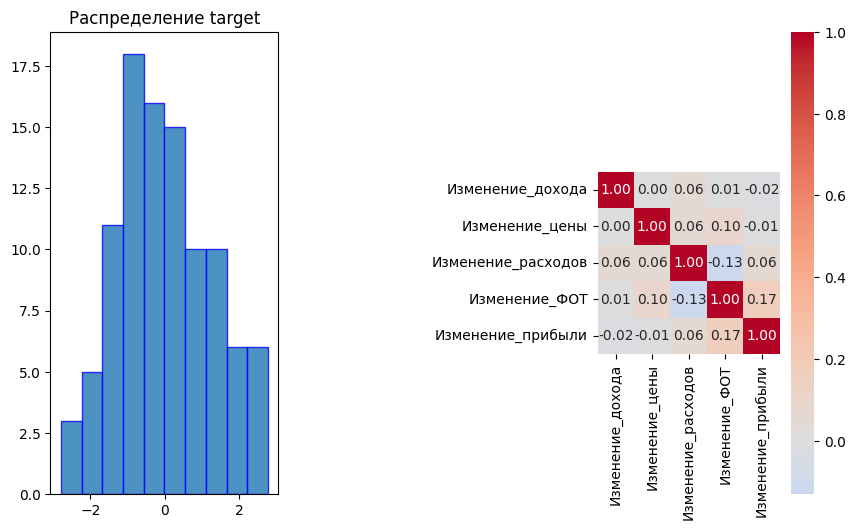

In [13]:
plt.figure(figsize = (10, 6))
plt.subplot(1, 3, 1)
plt.hist(df['target'], bins = 10, edgecolor = 'blue', alpha = 0.8)
plt.title('Распределение target')
plt.subplot(1, 3, 3)
columns_for_corr = ["Изменение_дохода", "Изменение_цены", "Изменение_расходов", "Изменение_ФОТ", "Изменение_прибыли"]
corr = df[columns_for_corr].corr()
sns.heatmap(corr, annot = True, cmap = 'coolwarm', center = 0, fmt = '.2f', square = True)
plt.show()

In [18]:
iris = load_iris()
print(iris.keys())
df_iris = pd.DataFrame(iris.data, columns = iris.feature_names)
df_iris['target'] = iris.target
df_iris['species'] = df_iris['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
print(df_iris.head())
print('Размер: ', df_iris.shape)
print('Типы данных \n')
print(df_iris.dtypes)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  
Размер:  (150, 6)
Типы данных 

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
species                  str
dtype: object


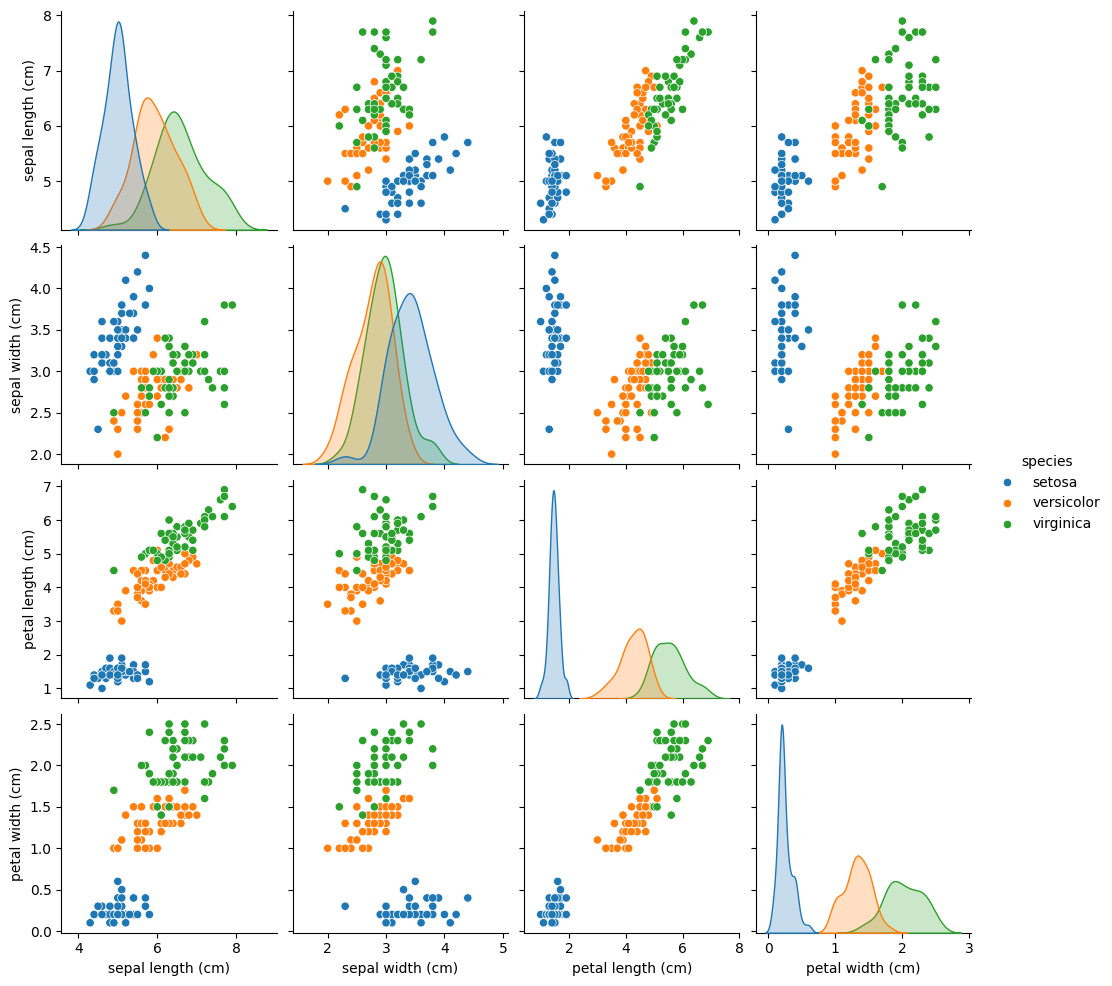

In [20]:
sns.pairplot(df_iris, hue = 'species', vars = iris.feature_names)
plt.show()

Точность модели: {accuracy: .3f}
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



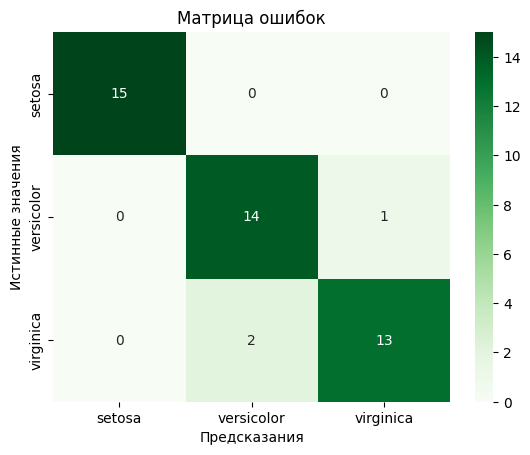

In [28]:
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    random_state = 42,
    stratify = y
)
model = LogisticRegression(max_iter = 200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Точность модели: {accuracy: .3f}")
print(classification_report(y_test, y_pred, target_names = iris.target_names))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Greens',
           xticklabels = iris.target_names,
            yticklabels = iris.target_names)
plt.title("Матрица ошибок")
plt.xlabel("Предсказания")
plt.ylabel("Истинные значения")
plt.show()